## Importamos librerias

In [ ]:
# Importamos librerias principales
# Pandas, numpy
import numpy as np
import pandas as pd

# Division de datos
from sklearn.model_selection import train_test_split

# Regresion Logistica
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, recall_score
# from sklearn.preprocessing import MinMaxScaler

# Arbol de desicion y Random Forest
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier

# Modelos de regresion
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn import metrics
from sklearn.model_selection import KFold, cross_validate, GridSearchCV

# Libreria para calcular curtosis
from scipy.stats import kurtosis, skew

# Visualizadores
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Guardamos los datos en un DataFrame
df = pd.read_csv('/content/FraudeCanastas.csv')

## Analisis exploratorio

In [ ]:
# Exploramos las dimensiones del DataSet
df.shape

(9319, 2457)

In [ ]:
# Visualizamos los primeros registros
df.head()

,ID,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
0,130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
1,195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
2,217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
3,552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
4,854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


In [ ]:
# Observamos numero de registros con fraude
df['fraud_flag'].value_counts()

,count
fraud_flag,
0.0,8000
1.0,1319


In [ ]:
# Porcentaje de registros con fraude
df['fraud_flag'].value_counts(normalize=True)

,proportion
fraud_flag,
0.0,0.858461
1.0,0.141539


In [ ]:
# Contamos valores nulos
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Eliminamos el ID por ser una columna que no aporta información valiosa
df = df.drop('ID', axis=1)

### No se tienen valores nulos

## Division inicial

In [ ]:
df_train, df_test = train_test_split(df,
                                     test_size=0.20,
                                     shuffle=True,
                                     random_state=8,
                                     stratify=df['fraud_flag'])

print("Registros en Train:", len(df_train))
print("Registros en Test:", len(df_test))


Registros en Train: 7455
Registros en Test: 1864


In [ ]:
# Separamos variables objetivo y explicativas
y_test = df_test['fraud_flag']
y_train = df_train['fraud_flag']
X_test = df_test.drop('fraud_flag', axis=1)
X_train = df_train.drop('fraud_flag', axis=1)

## Entrenamiento de modelo Regresion Logistica

In [ ]:
clasificador_rl = LogisticRegression(penalty= None,
                                     random_state=4,
                                     max_iter=1500,        # Default 100
                                     tol=0.0001,           # Default 1e-4
                                     solver="sag").fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# Se usa recall score para saber qué tan bien está detectando los fraudes

def evaluacion(modelo, graph_size=(10, 4)):
  """
  Evalúa el modelo tanto en el conjunto de entrenamiento como en el de prueba
  y muestra las matrices de confusión para ambos in a row.

  Args:
    modelo: El modelo entrenado a evaluar.
    graph_size: The size of the figure for the heatmaps.
  """

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(graph_size[0], graph_size[1]))

  # Evaluar en el conjunto de entrenamiento

#  recall_score = modelo.score(X_train, y_train) * 100

  data = {'y_Real': y_train, 'y_Prediccion': modelo.predict(X_train)}
  df = pd.DataFrame(data, columns=['y_Real', 'y_Prediccion'])
  confusion_matriX_train = pd.crosstab(df['y_Real'],
                                       df['y_Prediccion'],
                                       rownames=['Real'],
                                       colnames=['Predicción'])
  sns.heatmap(
      confusion_matriX_train,
      annot=True, fmt='g', ax=ax1
      ).set(title='df_train: entrenamiento')

  # Evaluar en el conjunto de prueba
#  recall_score = modelo.score(X_test, y_test) * 100

  data = {'y_Real': y_test, 'y_Prediccion': modelo.predict(X_test)}
  df = pd.DataFrame(data, columns=['y_Real', 'y_Prediccion'])
  confusion_matriX_test = pd.crosstab(df['y_Real'],
                                      df['y_Prediccion'],
                                      rownames=['Real'],
                                      colnames=['Predicción'])
  sns.heatmap(
      confusion_matriX_test,
      annot=True, fmt='g', ax=ax2
      ).set(title='df_train: prueba')
  plt.tight_layout()
  plt.show()

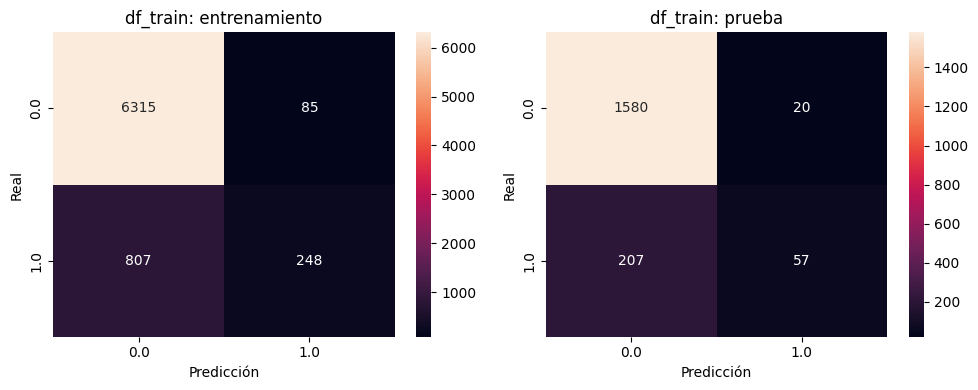

In [ ]:
evaluacion(modelo=clasificador_rl)

In [ ]:
y_train_pred = clasificador_rl.predict(X_train)
y_pred = clasificador_rl.predict(X_test)
print("Recall score del modelo Bosque Aleatorio en el conjunto de entrenamiento: {:4.2f}%".format(recall_score(y_train, y_train_pred )*100))
print("Recall score del modelo Bosque Aleatorio en el conjunto de prueba: {:4.2f}%".format(recall_score(y_test, y_pred)*100))

Recall score del modelo Bosque Aleatorio en el conjunto de entrenamiento: 23.51%
Recall score del modelo Bosque Aleatorio en el conjunto de prueba: 21.59%


### Se tiene un recall score bajo, por lo que se evaluarán otros modelos

## Entrenamiento de modelo Arbol de desición

In [ ]:
profundidad = None

# Entrenamiento del modelo.
clasificador_arbol = DecisionTreeClassifier(max_depth=profundidad,
                                      criterion="entropy",
                                      random_state=0)
clasificador_arbol.fit(X_train, y_train)
print("La profundida del árbol es: {}".format(clasificador_arbol.get_depth()))

La profundida del árbol es: 53


In [ ]:
# Predicción y evaluación sobre el conjunto de entrenamiento.
y_pred_train = clasificador_arbol.predict(X_train)
exactitud_train = recall_score(y_train, y_pred_train)*100
print("Recall_score conjunto de entrenamiento: {:4.2f}%".format(exactitud_train))

# Predicción y evaluación sobre el conjunto de prueba.
y_pred_test = clasificador_arbol.predict(X_test)
exactitud_test = recall_score(y_test, y_pred_test)*100
print("Recall_score conjunto de prueba: {:4.2f}%".format(exactitud_test),'\n')

Recall_score conjunto de entrenamiento: 53.18%
Recall_score conjunto de prueba: 38.26% 



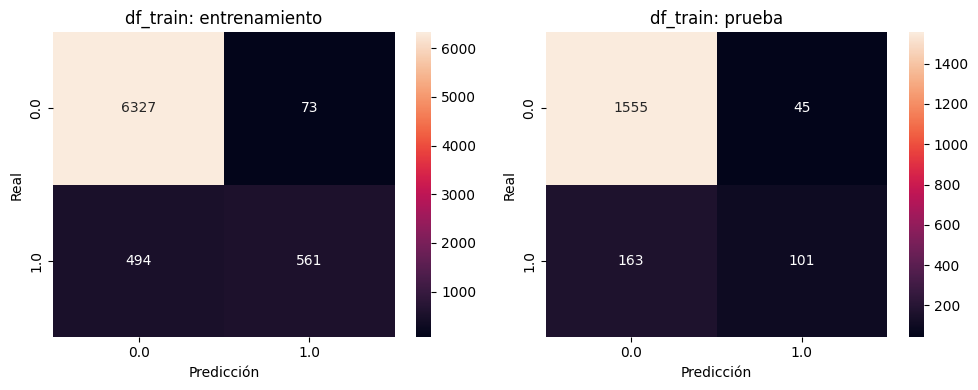

In [ ]:
evaluacion(modelo=clasificador_arbol)

No se obtienen los resultados esperados, se tienen muchos falsos positivos, se cambiará el umbral con el cual el modelo determina si es fraude o no

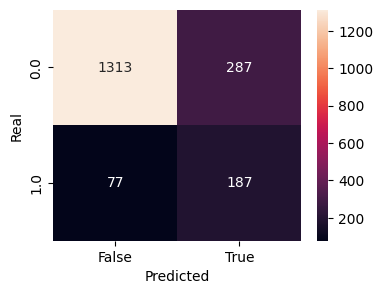

Recall Score del modelo arbol de desicion en el conjunto de prueba: 70.83%


In [ ]:
umbral = 0.15 # por arriba del cual se clasificaría como clase 1
prediccion_test = np.where( clasificador_arbol.predict_proba(X_test)[:, 1] > umbral, True, False)
data = {'y_Real':  y_test,
        'y_Prediccion': prediccion_test
        }

evaluacion_df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'], rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

print("Recall Score del modelo arbol de desicion en el conjunto de prueba: {:4.2f}%".format(recall_score(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'])*100))

Se obtuvo un resultado satisfactorio, un recall score de 71%, además, se mantiene alto el numero de verdaderos negativos

Se hará una evaluación con modelo Random Forest

## Entrenamiento de Random Forest

In [ ]:
clf_rf = RandomForestClassifier(n_estimators=1000,  random_state =0,
                                criterion='entropy').fit(X_train, y_train)

y_train_pred = clf_rf.predict(X_train)
y_pred = clf_rf.predict(X_test)
print("Recall score del modelo Bosque Aleatorio en el conjunto de entrenamiento: {:4.2f}%".format(recall_score(y_train, y_train_pred )*100))
print("Recall score del modelo Bosque Aleatorio en el conjunto de prueba: {:4.2f}%".format(recall_score(y_test, y_pred)*100))

Exactitud del modelo Bosque Aleatorio en el conjunto de entrenamiento: 54.12%
Exactitud del modelo Bosque Aleatorio en el conjunto de prueba: 33.71%


Top 10 features:
costo_total                                                               0.101028
costo_medio_item                                                          0.100955
costo_item_max                                                            0.088706
costo_item_min                                                            0.083295
FULFILMENT CHARGE | RETAILER | RETAILER                                   0.053349
COMPUTERS | APPLE | 2021 APPLE IPAD PRO 12 9 M1 PROCESSOR IOS WI-FI CE    0.022265
COMPUTERS | APPLE | 2021 APPLE MACBOOK PRO 14 M1 PRO PROCESSOR 16GB RA    0.021003
COMPUTERS | APPLE | 2020 APPLE MACBOOK PRO 13 TOUCH BAR M1 PROCESSOR 8    0.019973
total_of_items                                                            0.019517
COMPUTERS | APPLE | 2020 APPLE MACBOOK PRO 13 TOUCH BAR INTEL CORE I5     0.019043
Nb_of_items                                                               0.018404
COMPUTERS | APPLE | 2021 APPLE IPAD PRO 11 M1 PROCESSOR IOS WI-FI CELL

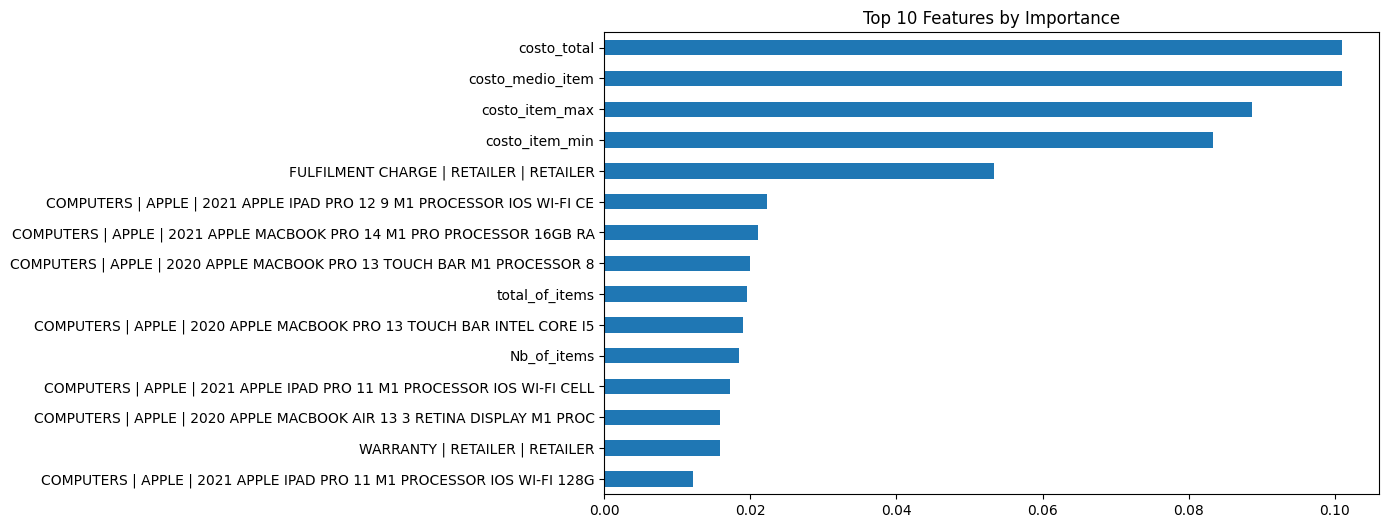

In [ ]:
importances = clf_rf.feature_importances_
weights = pd.Series(importances,
                    index=X_train.columns.values)

# Get the top 10 features
top_10_features = weights.nlargest(15)

print("Top 10 features:")
print(top_10_features)

top_10_features.sort_values(ascending=True).plot(kind = 'barh', figsize=(10, 6), title='Top 10 Features by Importance')
plt.show()

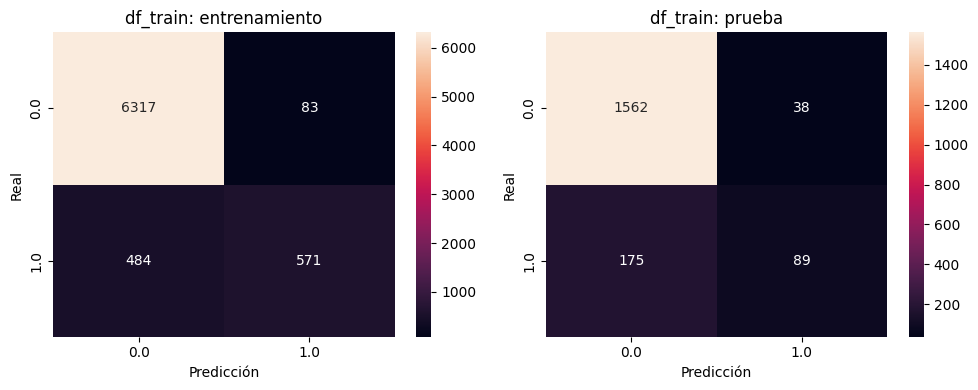

In [ ]:
evaluacion(modelo=clf_rf)

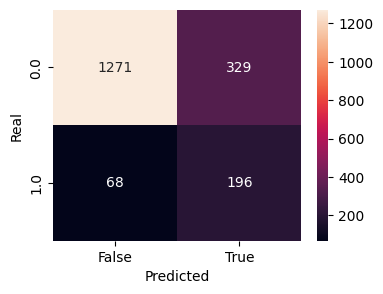

Exactitud del modelo Bosque Aleatorio en el conjunto de prueba: 74.24%


In [ ]:
umbral = 0.15 # por arriba del cual se clasificaría como clase 1
prediccion_test = np.where( clf_rf.predict_proba(X_test)[:, 1] > umbral, True, False)
data = {'y_Real':  y_test,
        'y_Prediccion': prediccion_test
        }

evaluacion_df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'], rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

print("Exactitud del modelo Bosque Aleatorio en el conjunto de prueba: {:4.2f}%".format(recall_score(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'])*100))

Se tiene un buen resultado, no varía mucho con el modelo de Arbo de Desición pero disminuye el numero de verdaderos positivos

Recomendación: Elegir el modelo de arbol de desición

## Fase II

In [ ]:
#df_reg = df.drop(['Nb_of_items',	'total_of_items',	'costo_total',	'costo_medio_item',	'costo_item_max',	'costo_item_min', 'fraud_flag'], axis=1)

In [ ]:
df_reg = df.copy()

### Transformación inicial de los datos

In [ ]:
df_reg.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0


In [ ]:
# Se agrega columna con suma de coordenadas en cada registro de la base de datos con la que comenzamos
df_reg['valor_fraude'] = df_reg.iloc[:, :-7].sum(axis=1)
display(df_reg.head())

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag,valor_fraude
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2,2,1299,649.500000,1299,0.0,1.0,1299.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3,3,4119,1373.000000,2470,0.0,1.0,4119.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2,2,2806,1403.000000,2799,7.0,1.0,2806.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2,2,1206,603.000000,1199,7.0,1.0,1206.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,19,27,1807,66.925926,195,4.0,1.0,1807.0


In [ ]:
# Se cambia cada columna en las características en una variable binaria que únicamente indica la presencia o ausencia de un artículo en la canasta.
columns_to_transform = df_reg.columns[:-8]
df_reg[columns_to_transform] = df_reg[columns_to_transform].apply(lambda x: (x > 0).astype(int))
df_reg.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag,valor_fraude
0,0,0,0,0,0,0,0,0,0,0,...,0,0,2,2,1299,649.500000,1299,0.0,1.0,1299.0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,3,3,4119,1373.000000,2470,0.0,1.0,4119.0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,2,2,2806,1403.000000,2799,7.0,1.0,2806.0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,2,2,1206,603.000000,1199,7.0,1.0,1206.0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,19,27,1807,66.925926,195,4.0,1.0,1807.0


In [ ]:
# Se elimina variable objetivo anterior
df_reg = df_reg.drop('fraud_flag', axis=1)
df_reg.head()

,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,valor_fraude
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,1299,649.500000,1299,0.0,1299.0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3,3,4119,1373.000000,2470,0.0,4119.0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,2806,1403.000000,2799,7.0,2806.0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,1206,603.000000,1199,7.0,1206.0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,19,27,1807,66.925926,195,4.0,1807.0


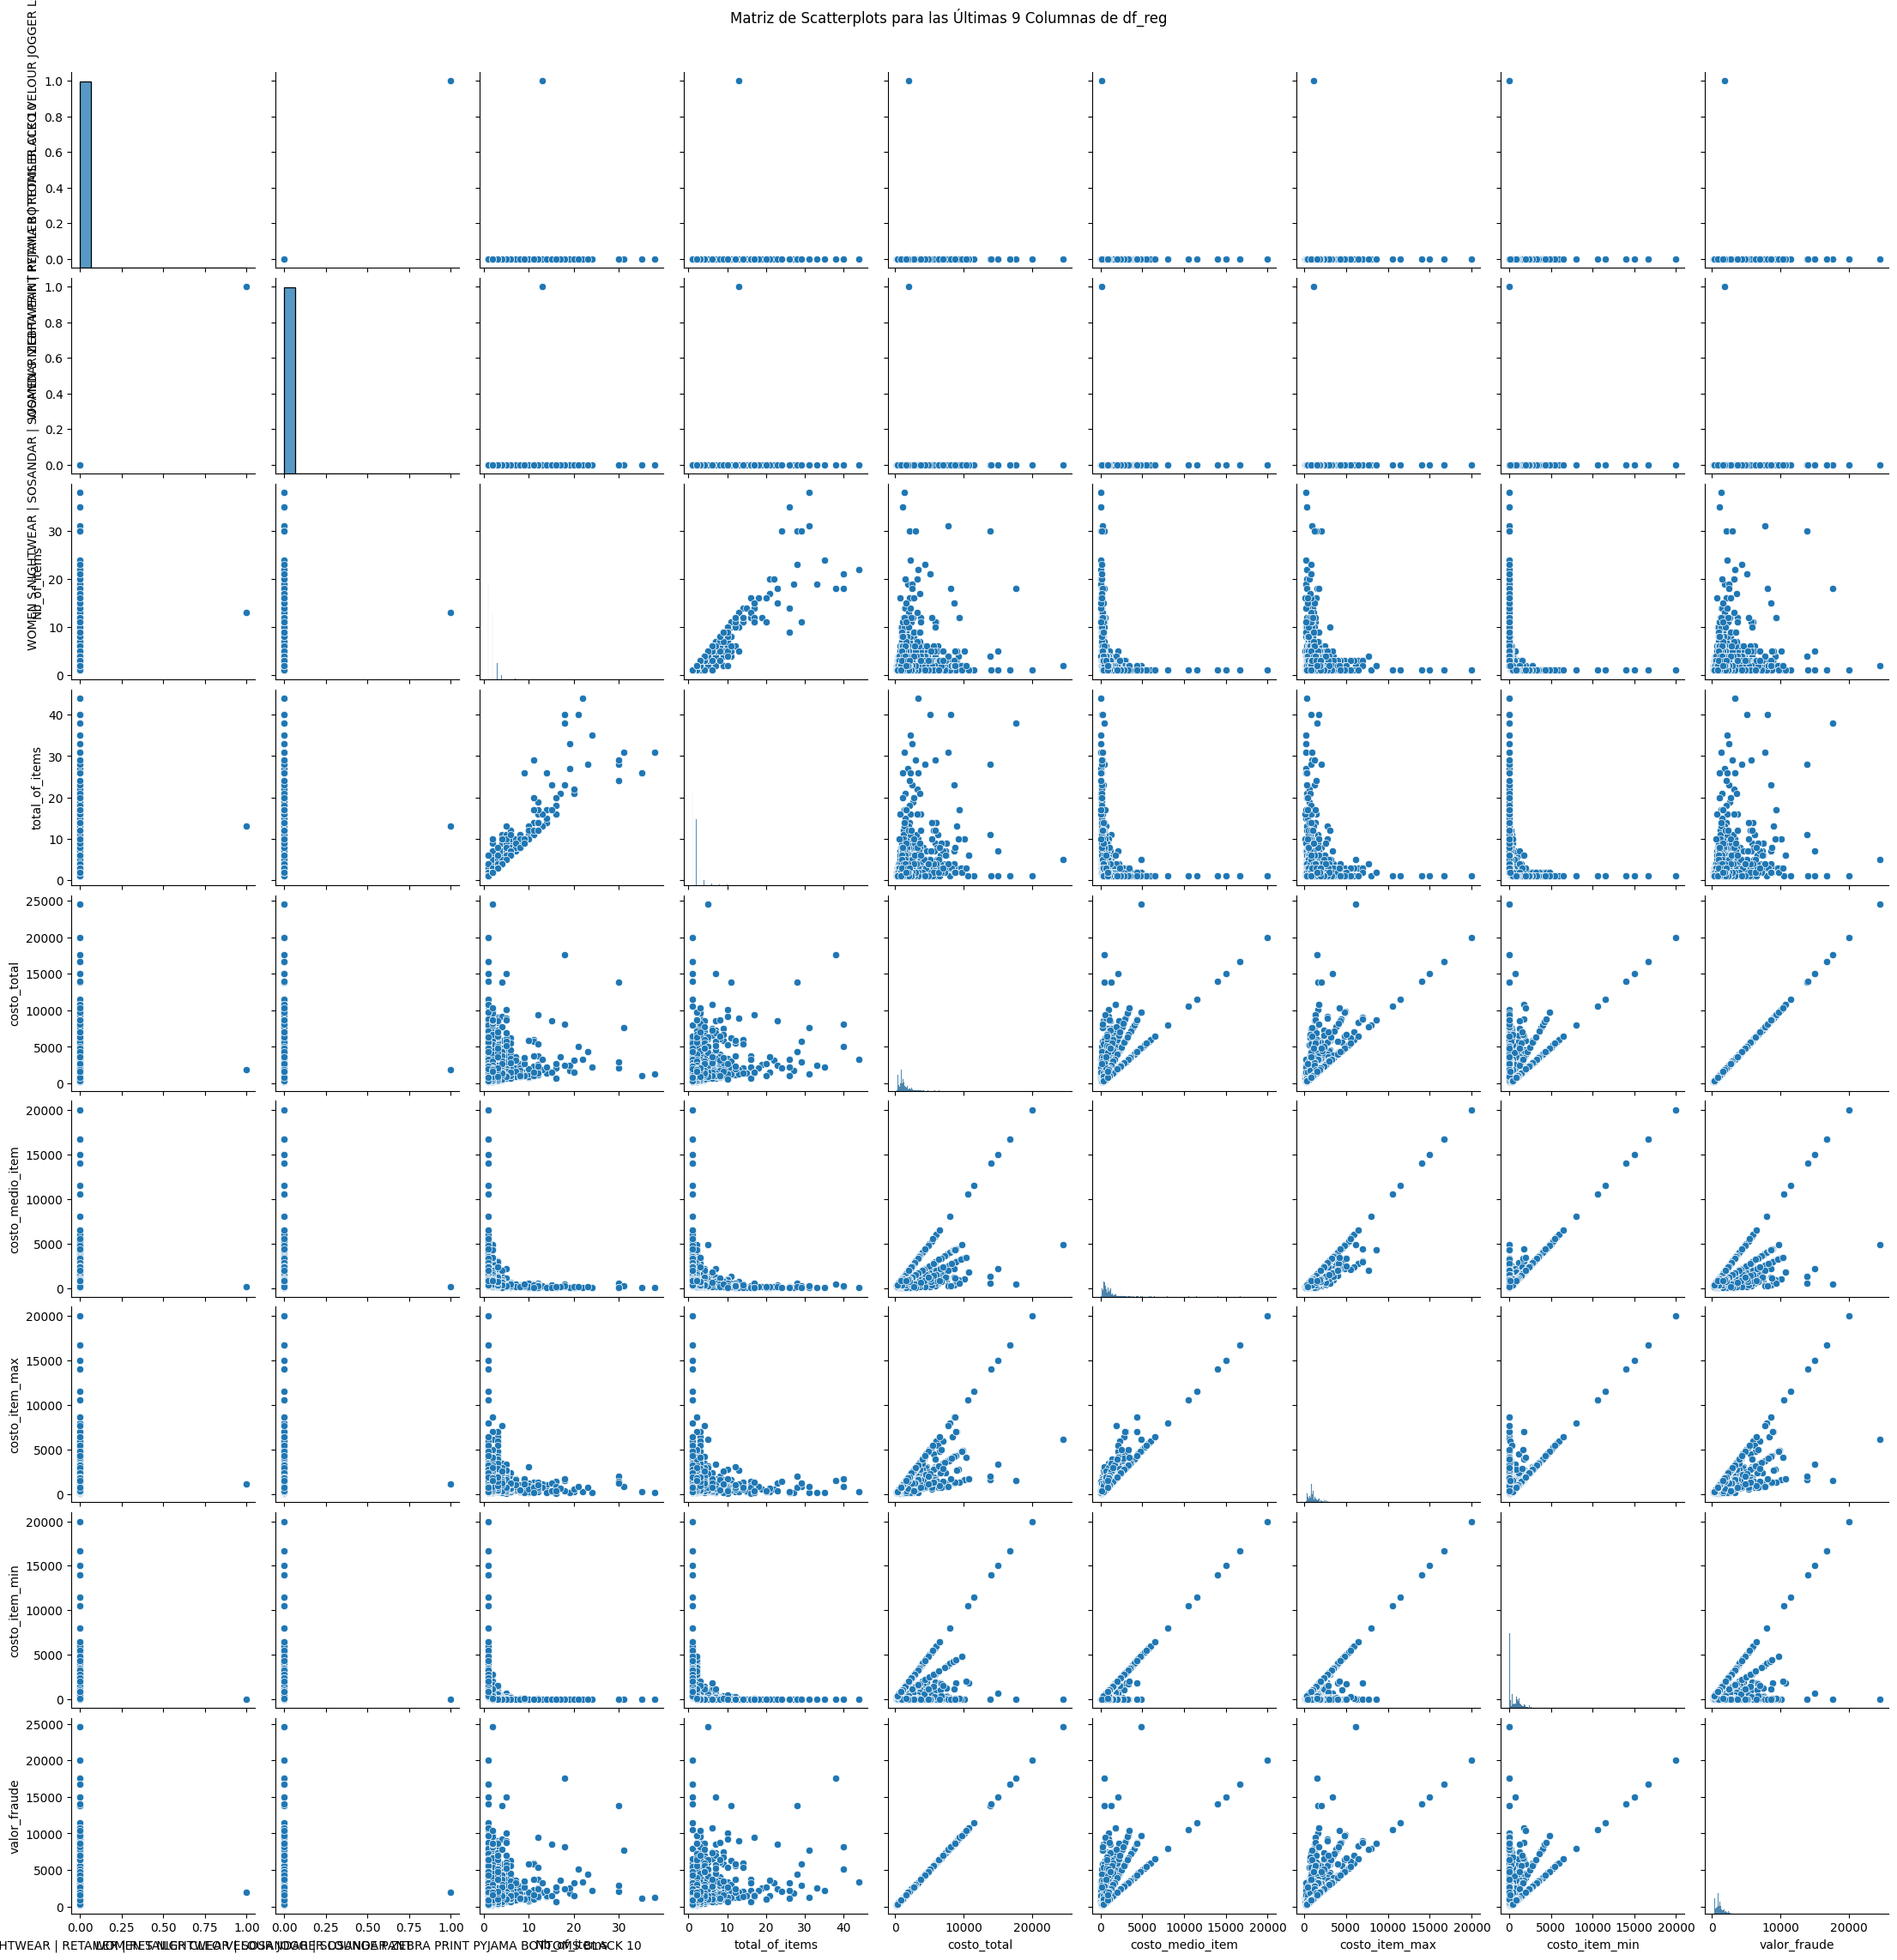

In [ ]:
sns.pairplot(df_reg.iloc[:, -9:])
plt.suptitle('Matriz de Scatterplots para las Últimas 9 Columnas de df_reg', y=1.02)
plt.show()

## Division de variables y analisis exploratorio

In [ ]:

y = df_reg['valor_fraude']
X = df_reg.drop([ 'valor_fraude'], axis=1)


In [ ]:
df_reg['valor_fraude'].describe()

,valor_fraude
count,9319.000000
mean,1337.801052
std,1070.597321
min,219.000000
25%,838.000000
50%,1124.000000
75%,1612.000000
max,24551.000000


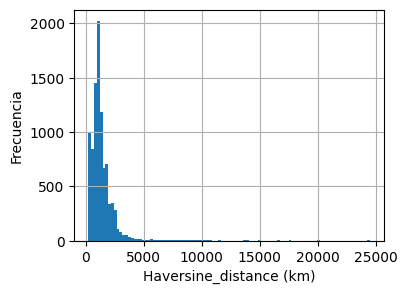

In [ ]:
plt.figure(figsize=(4, 3))
df_reg['valor_fraude'].hist(bins=100)
plt.xlabel('Haversine_distance (km)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
ultimas_col = df_reg.columns[-7:]

corr_y = df_reg[ultimas_col].corr()['valor_fraude']
corr_y.sort_values()

,valor_fraude
Nb_of_items,0.209340
total_of_items,0.294593
costo_item_min,0.401416
costo_medio_item,0.660719
costo_item_max,0.810710
costo_total,1.000000
valor_fraude,1.000000


In [ ]:

no_relevantes = corr_y.loc[corr_y.abs()<0.1].index.to_list()
no_relevantes

[]

In [ ]:

def correlacion(dataframe, grafica=True, matrix=True, tamaño =(6, 4)):
    '''
    Funcion para obtener la matriz de correlacion y visualizarla en mapa de calor.
    '''
    corr=dataframe.corr()
    if grafica==True:
      fig = plt.figure(figsize = tamaño)
      ax = sns.heatmap(corr,
                       vmin = -1,
                       vmax = 1,
                       center = 0,
                       cmap = "coolwarm",
                       annot = True,
                       fmt=".2f",
                       square = True)
      ax.set_xticklabels(ax.get_xticklabels(),
                         rotation = 45,
                         horizontalalignment ='right')
    if matrix==True:
      return corr


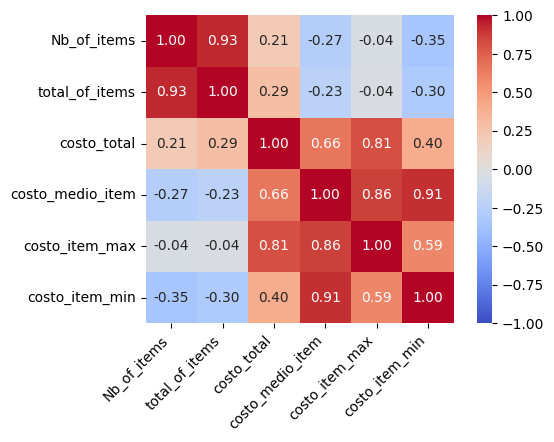

In [ ]:

# correlacion de las características numéricas en el conjunto X
corr_matrix = correlacion(df_reg[ultimas_col].drop('valor_fraude', axis=1))

In [ ]:

#Identificar variables redundantes

# Triangulo superior de la matriz de correlación en números absolutos
celda_sobre_diagonal_ppal = np.triu(np.ones_like(corr_matrix), 1).astype(bool)
triangulo_sup = corr_matrix.where(celda_sobre_diagonal_ppal).abs()


# Encontrar las columnas donde la correlación es 1
redundantes = [column for column in triangulo_sup.columns
          if any(triangulo_sup[column] >= .7)]
redundantes

['total_of_items', 'costo_item_max', 'costo_item_min']

In [ ]:
df_reg = df_reg.drop(redundantes + no_relevantes, axis=1)

In [ ]:

df.columns

Index(['APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90',
       'AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H',
       'AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE',
       'AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI',
       'AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE',
       'AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND',
       'AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD',
       'AUDIO ACCESSORIES | APPLE | AIRPODS PRO',
       'AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX',
       'AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX NOISE CANCELLING WIRELESS BLUETO',
       ...
       'WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY',
       'WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT',
       'WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA

## Modelo de regresion

In [ ]:
# Línea base (error medio absoluto)
ema_base = np.mean(np.absolute(y - y.mean()))
print(f"""
El error de predecir el promedio del valor de fraude,
sin usar las caracteristicas explicativas (X) es {ema_base:.2f}
      """)


El error de predecir el promedio del valor de fraude,
sin usar las caracteristicas explicativas (X) es 620.83
      


In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
model = LinearRegression()
cv_results = cross_validate(
    estimator=model,
    X=X,
    y=y,
    cv=cv,
    return_train_score=True,
    return_estimator=True,
    scoring='neg_mean_absolute_error',  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

In [ ]:
# cambiamos el signo para obtener MAE
df_scores = pd.DataFrame({'train_score': -cv_results['train_score'],
                          'test_score': -cv_results['test_score']
                          })
df_scores

,train_score,test_score
0,3.838676e-13,4.634690e-13
1,3.573301e-13,3.941530e-13
2,5.879976e-13,6.869393e-13
3,1.744728e-12,1.828992e-12
4,6.119970e-13,6.017657e-13
5,6.564951e-13,7.944661e-13
6,4.258478e-13,4.698426e-13
7,1.071594e-12,1.108630e-12
8,6.414624e-13,7.031628e-13
9,6.177486e-13,7.529463e-13


In [ ]:

print("\nMean cross-validation MAE:", df_scores['test_score'].mean())
print("Standard deviation of cross-validation MAE:", df_scores['test_score'].std())


Mean cross-validation MAE: 7.80436634937032e-13
Standard deviation of cross-validation MAE: 4.217581993171988e-13


In [ ]:

errores = []
for i, (train_index, test_index) in enumerate(cv.split(X, y)):
    X_test_fold = X.iloc[test_index]
    y_test_fold = y.iloc[test_index]

    model = cv_results['estimator'][i]
    y_pred_fold = model.predict(X_test_fold)
    errores_fold = (y_test_fold - y_pred_fold)
    errores.extend( errores_fold)

errores = np.array(errores)

len(errores), len (y)  # ahora tenemos un error de predicción para cada y

(9319, 9319)

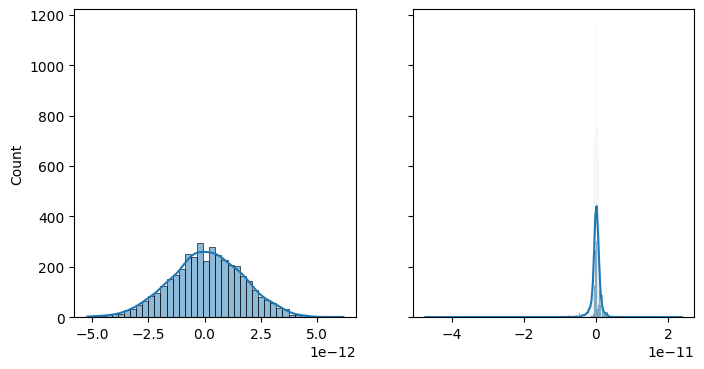

In [ ]:
media = np.mean(errores)
des_est = np.std(errores)
errores_teoricos = np.random.normal(media, des_est, 3930)


fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
for dat, subplot in zip((errores_teoricos, errores), ax.flatten()):
    sns.histplot(x=dat, ax=subplot, kde=True )

plt.show()

In [ ]:

print(f'kurtosis: {kurtosis(errores)}')

kurtosis: 158.79047297683104


In [ ]:

print(f'kurtosis: {kurtosis(errores_teoricos)}')

kurtosis: -0.05362553115855473


### Se obtuvo una kurtosis elevada, por lo que se evaluará una regresión robusta

## CV para regresion Huber

In [ ]:
# Busqueda de hiperparametro epsilon
%%time
cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

model_hr = HuberRegressor(max_iter=5000,  alpha=0,  warm_start=True,
                          fit_intercept=False, tol=1e-05)

model_grid_search = GridSearchCV(estimator=model_hr,
                           param_grid={
                               'epsilon':[1.25, 1.35]  # Se recomienda un rango entre 1 y 2
                           },
                           scoring='neg_mean_absolute_error',
                           cv= cv_grid,   # estrategia de separación del conjunto de datos
                           verbose=3
                               # Al final entrena el modelo con los mejores parametros en todos los datos
                           )
cv = KFold(n_splits=3, shuffle=True, random_state=6)
cv_results = cross_validate(
    estimator=model_grid_search,
    X=X,
    y=y,
    cv=cv,
    #return_train_score=True,
    return_estimator=True,
    scoring='neg_mean_absolute_error',  # el algoritmo de optimización que usa sklearn maximisa este valor.
)




Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV 1/5] END .....................epsilon=1.25;, score=-0.000 total time= 3.6min
[CV 2/5] END .....................epsilon=1.25;, score=-0.000 total time= 2.2min
[CV 3/5] END .....................epsilon=1.25;, score=-0.000 total time= 9.3min
[CV 4/5] END .....................epsilon=1.25;, score=-0.000 total time= 9.1min
[CV 5/5] END .....................epsilon=1.25;, score=-0.000 total time= 1.3min
[CV 1/5] END .....................epsilon=1.35;, score=-0.000 total time=10.1min
[CV 2/5] END .....................epsilon=1.35;, score=-0.000 total time=16.5min
[CV 3/5] END .....................epsilon=1.35;, score=-0.000 total time=13.1min
[CV 4/5] END .....................epsilon=1.35;, score=-0.000 total time=15.2min
[CV 5/5] END .....................epsilon=1.35;, score=-0.000 total time=12.9min
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV 1/5] END .....................epsilon=1.25;, score=-0.000 total ti

In [ ]:

for cv_fold, estimator_in_fold in enumerate(cv_results["estimator"]):
    print(
        f"Best hyperparameters for fold #{cv_fold + 1}:\n"
        f"{estimator_in_fold.best_params_}"
    )

Best hyperparameters for fold #1:
{'epsilon': 1.35}
Best hyperparameters for fold #2:
{'epsilon': 1.35}
Best hyperparameters for fold #3:
{'epsilon': 1.35}


In [ ]:

df_scores = pd.DataFrame({'test_score': -cv_results['test_score']
                          })
df_scores

,test_score
0,0.000004
1,0.000013
2,0.000004


## Evaluacion del modelo

In [ ]:

print("Mean cross-validation MAE:", df_scores['test_score'].mean())
print("Standard deviation of cross-validation MAE:", df_scores['test_score'].std())

Mean cross-validation MAE: 6.971863135331711e-06
Standard deviation of cross-validation MAE: 5.164724738708644e-06


In [ ]:

errores = []
for i, (train_index, test_index) in enumerate(cv.split(X, y)):
    X_test_fold = X.iloc[test_index]
    y_test_fold = y.iloc[test_index]

    model = cv_results['estimator'][i]
    y_pred_fold = model.predict(X_test_fold)
    errores_fold = (y_test_fold - y_pred_fold)
    errores.extend( errores_fold)

errores = np.array(errores)

len(errores), len (y)  # ahora tenemos un error de predicción para cada y

(9319, 9319)

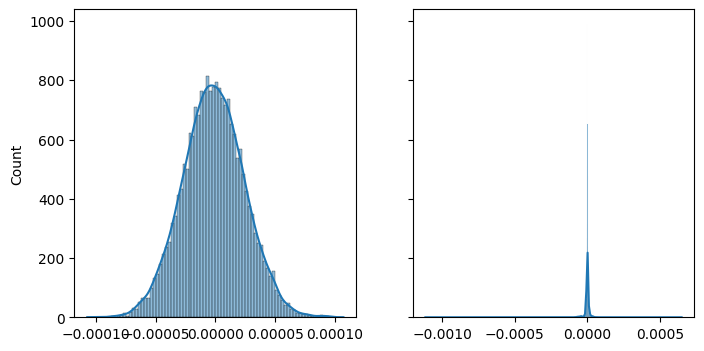

In [ ]:

media = np.mean(errores)
des_est = np.std(errores)
errores_teoricos = np.random.normal(media, des_est, 20337)


fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
for dat, subplot in zip((errores_teoricos, errores), ax.flatten()):
    sns.histplot(x=dat, ax=subplot, kde=True )

plt.show()

In [ ]:

print(f'kurtosis: {kurtosis(errores)}')


kurtosis: 887.1680884085154


In [ ]:

for cv_fold, estimator_in_fold in enumerate(cv_results["estimator"]):
    print(
        f"Best hyperparameters for fold #{cv_fold + 1}:\n"
        f"{estimator_in_fold.best_params_}"
    )

Best hyperparameters for fold #1:
{'epsilon': 1.35}
Best hyperparameters for fold #2:
{'epsilon': 1.35}
Best hyperparameters for fold #3:
{'epsilon': 1.35}


In [ ]:

df_scores = pd.DataFrame({'test_score': -cv_results['test_score']
                          })
df_scores

,test_score
0,0.000004
1,0.000013
2,0.000004


### La curtosis aumentó, con respecto al modelo que usa la regresion lineal simple, por lo cual nos quedaremos con la regresión lineal simple

In [ ]:
modelo_final = LinearRegression().fit(X, y)

In [ ]:

coeficientes_df = pd.DataFrame({'Característica': X.columns, 'Coeficiente': modelo_final.coef_})
coeficientes_df.sort_values(by='Coeficiente', ascending=False, inplace=True)
coeficientes_df

,Característica,Coeficiente
2451,costo_total,1.000000e+00
2395,TELEVISIONS HOME CINEMA | SONY | SONY SA-RS3S ...,9.957355e-12
1,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR...,9.803713e-12
19,AUDIO ACCESSORIES | BOSE | BOSE SOUNDSPORT SWE...,8.611300e-12
1742,LIVING DINING FURNITURE | RETAILER | RETAILER ...,4.785477e-12
...,...,...
2345,TELEVISIONS HOME CINEMA | SAMSUNG | SAMSUNG QE...,-6.943663e-12
1897,OUTDOOR FURNITURE | CRANE GARDEN BUILDINGS | C...,-7.029688e-12
1898,OUTDOOR FURNITURE | CRANE GARDEN BUILDINGS | C...,-7.470697e-12
2357,TELEVISIONS HOME CINEMA | SAMSUNG | SAMSUNG UE...,-7.696975e-12


### Se observa que el costo total es directamente proporcional con una correlacion practicamente perfecta, lo cual es una mala señal para el modelo

## Prueba sin costo_total

In [ ]:
X2 = X.drop(['costo_total'], axis=1)

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
model = LinearRegression()
cv_results = cross_validate(
    estimator=model,
    X=X2,
    y=y,
    cv=cv,
    return_train_score=True,
    return_estimator=True,
    scoring='neg_mean_absolute_error',  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

In [ ]:
# cambiamos el signo para obtener MAE
df_scores = pd.DataFrame({'train_score': -cv_results['train_score'],
                          'test_score': -cv_results['test_score']
                          })
df_scores

,train_score,test_score
0,81.203716,149.682904
1,81.880242,197.574959
2,78.079090,177.483065
3,66.732697,157.907431
4,80.040195,172.561020
5,82.791873,203.829949
6,79.691873,152.444120
7,78.205157,178.871700
8,80.475159,217.668005
9,81.577663,190.432947


In [ ]:
print("\nMean cross-validation MAE:", df_scores['test_score'].mean())
print("Standard deviation of cross-validation MAE:", df_scores['test_score'].std())


Mean cross-validation MAE: 179.8456099653842
Standard deviation of cross-validation MAE: 22.69046103049612


In [ ]:

errores = []
for i, (train_index, test_index) in enumerate(cv.split(X2, y)):
    X_test_fold = X2.iloc[test_index]
    y_test_fold = y.iloc[test_index]

    model = cv_results['estimator'][i]
    y_pred_fold = model.predict(X_test_fold)
    errores_fold = (y_test_fold - y_pred_fold)
    errores.extend( errores_fold)

errores = np.array(errores)

len(errores), len (y)  # ahora tenemos un error de predicción para cada y

(9319, 9319)

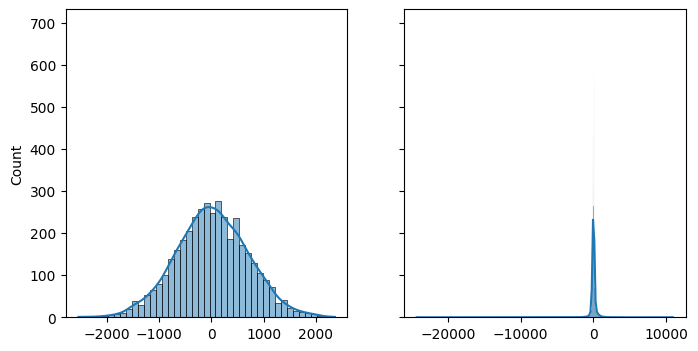

In [ ]:
media = np.mean(errores)
des_est = np.std(errores)
errores_teoricos = np.random.normal(media, des_est, 3930)


fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
for dat, subplot in zip((errores_teoricos, errores), ax.flatten()):
    sns.histplot(x=dat, ax=subplot, kde=True )

plt.show()

In [ ]:

print(f'kurtosis: {kurtosis(errores)}')

kurtosis: 450.5757326615134


## CV para regresion Huber

In [ ]:
# Busqueda de hiperparametro epsilon
%%time
cv_grid = KFold(n_splits=3, shuffle=True, random_state=42)

model_hr = HuberRegressor(max_iter=5000,  alpha=0,  warm_start=True, tol=1e-05)

model_grid_search = GridSearchCV(estimator=model_hr,
                           param_grid={
                               'epsilon':[1.25, 1.35]  # Se recomienda un rango entre 1 y 2
                           },
                           scoring='neg_mean_absolute_error',
                           cv= cv_grid,   # estrategia de separación del conjunto de datos
                           verbose=3
                               # Al final entrena el modelo con los mejores parametros en todos los datos
                           )
cv = KFold(n_splits=3, shuffle=True, random_state=6)
cv_results = cross_validate(
    estimator=model_grid_search,
    X=X2,
    y=y,
    cv=cv,
    #return_train_score=True,
    return_estimator=True,
    scoring='neg_mean_absolute_error',  # el algoritmo de optimización que usa sklearn maximisa este valor.
)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV 1/3] END ...................epsilon=1.25;, score=-100.375 total time= 3.8min
[CV 2/3] END ...................epsilon=1.25;, score=-117.289 total time=  50.7s
[CV 3/3] END ...................epsilon=1.25;, score=-136.152 total time= 5.1min
[CV 1/3] END ...................epsilon=1.35;, score=-100.277 total time= 3.9min
[CV 2/3] END ...................epsilon=1.35;, score=-111.927 total time= 2.7min
[CV 3/3] END ...................epsilon=1.35;, score=-138.495 total time=  33.7s
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV 1/3] END ...................epsilon=1.25;, score=-126.038 total time=  36.0s
[CV 2/3] END ...................epsilon=1.25;, score=-116.484 total time=  59.2s
[CV 3/3] END ...................epsilon=1.25;, score=-116.724 total time= 5.6min
[CV 1/3] END ...................epsilon=1.35;, score=-122.440 total time= 2.4min
[CV 2/3] END ...................epsilon=1.35;, score=-118.887 total time

In [ ]:
for cv_fold, estimator_in_fold in enumerate(cv_results["estimator"]):
    print(
        f"Best hyperparameters for fold #{cv_fold + 1}:\n"
        f"{estimator_in_fold.best_params_}"
    )

Best hyperparameters for fold #1:
{'epsilon': 1.35}
Best hyperparameters for fold #2:
{'epsilon': 1.35}
Best hyperparameters for fold #3:
{'epsilon': 1.35}


In [ ]:
df_scores = pd.DataFrame({'test_score': -cv_results['test_score']
                          })
df_scores

,test_score
0,119.085377
1,114.470411
2,116.344409


In [ ]:
print("Mean cross-validation MAE:", df_scores['test_score'].mean())
print("Standard deviation of cross-validation MAE:", df_scores['test_score'].std())

Mean cross-validation MAE: 116.63339897970987
Standard deviation of cross-validation MAE: 2.3210158444929228


In [ ]:
errores = []

# Re-defining cv to match the splits used for cv_results (n_splits=3 in cell I1vq5nEBB_Go)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

print(f"Length of cv_results['estimator']: {len(cv_results['estimator'])}")
print(f"Number of splits in cv: {cv.get_n_splits(X2, y)}")

for i, (train_index, test_index) in enumerate(cv.split(X2, y)):
    X_test_fold = X2.iloc[test_index]
    y_test_fold = y.iloc[test_index]

    model = cv_results['estimator'][i]
    y_pred_fold = model.predict(X_test_fold)
    errores_fold = (y_test_fold - y_pred_fold)
    errores.extend( errores_fold)

errores = np.array(errores)

len(errores), len (y)  # ahora tenemos un error de predicción para cada y

Length of cv_results['estimator']: 3
Number of splits in cv: 3


(9319, 9319)

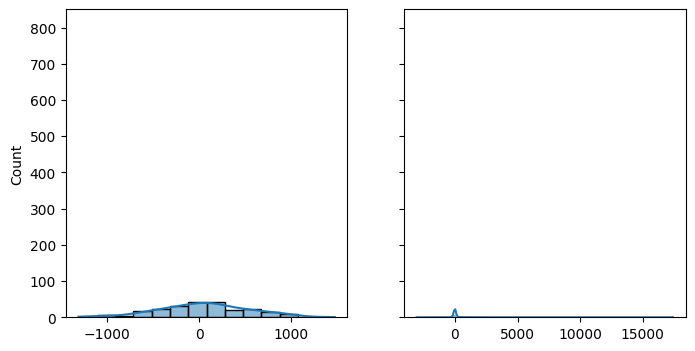

In [ ]:
media = np.mean(errores)
des_est = np.std(errores)
errores_teoricos = np.random.normal(media, des_est, 237)


fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
for dat, subplot in zip((errores_teoricos, errores), ax.flatten()):
    sns.histplot(x=dat, ax=subplot, kde=True )

plt.show()

In [ ]:

print(f'kurtosis: {kurtosis(errores)}')


kurtosis: 238.5654008266051


### La curtosis disminuye respecto a la regresion simple

## Conclusion modelo de Regresion

In [ ]:
modelo_final = HuberRegressor(alpha=0, epsilon=1.35, max_iter=5000,
               warm_start=True).fit(X2, y)

In [ ]:
coeficientes_df = pd.DataFrame({'Característica': X2.columns, 'Coeficiente': modelo_final.coef_})
coeficientes_df.sort_values(by='Coeficiente', ascending=False, inplace=True)
coeficientes_df

,Característica,Coeficiente
2450,total_of_items,169.172839
736,COMPUTER PERIPHERALS ACCESSORIES | APPLE | APP...,25.833811
748,COMPUTER PERIPHERALS ACCESSORIES | APPLE | APP...,23.475729
735,COMPUTER PERIPHERALS ACCESSORIES | APPLE | APP...,17.445043
10,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS PRO ...,16.928217
...,...,...
728,COMPUTER PERIPHERALS & ACCESSORIES | APPLE | A...,-26.792907
890,COMPUTERS | APPLE | 2020 APPLE MACBOOK AIR,-28.523709
2449,Nb_of_items,-34.557332
2402,WARRANTY | RETAILER | RETAILER,-62.449216
